# Brain Tumor Classification

Without dataset merge (training + testing) before preprocessing. Hence,

`Acquire -> Split (Train & Test) -> Preprocess -> Split (Train & Val) -> Extract`


## Library Imports


In [1]:
import os
from glob import glob
from zipfile import ZipFile

import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

import time

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Dataset Acquisition


### Import

In [2]:
data_path = "./data/"
dataset_file = data_path + "brain-sartaj.zip"

zip = ZipFile(dataset_file)
zip.extractall(data_path)
zip.close()

print(os.listdir(data_path))

['Training', 'Testing', 'brain-sartaj.zip']


### Train Test Split

In [3]:
train_path = os.path.join(data_path, "Training")
test_path = os.path.join(data_path, "Testing")

classes = os.listdir(train_path)

print("Classes:", classes)

Classes: ['meningioma_tumor', 'glioma_tumor', 'pituitary_tumor', 'no_tumor']


## Preprocessing

In [4]:
def preprocess(datapath, label, X, y, idx):
    images = glob(os.path.join(datapath, label, "*.jpg"))

    for img in images:
        img_raw = cv.imread(img)

        # Preprocess: Image Resizing
        img_resized = cv.resize(img_raw, (128, 128))

        # Preprocess: Image Grayscaling
        img_grayscaled = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)

        # # Preprocess: Image Normalizing
        # img_normalized = img_grayscaled / 255

        # X.append(img_normalized)
        X.append(img_grayscaled)
        y.append(idx)

In [5]:
X, y = [], []
X_test, y_test = [], []

for idx, label in enumerate(classes):
    preprocess(train_path, label, X, y, idx)
    preprocess(test_path, label, X_test, y_test, idx)

print("X data:", len(X))
print("y data:", len(y))
print("X_test data:", len(X_test))
print("y_test data:", len(y_test))

X data: 2870
y data: 2870
X_test data: 394
y_test data: 394


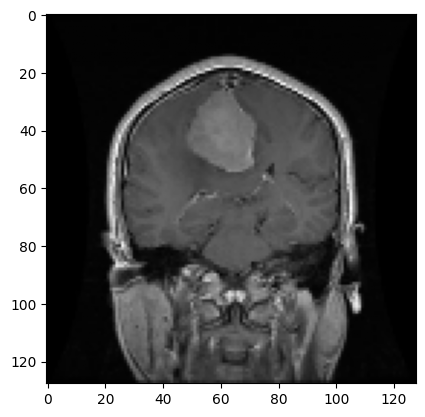

In [6]:
plt.imshow(X[0], cmap="gray")

### Data Splitting


In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42)

print("X_train data:", len(X_train))
print("y_train data:", len(y_train))
print("X_val data:", len(X_val))
print("y_val data:", len(y_val))

X_train data: 2296
y_train data: 2296
X_val data: 574
y_val data: 574


In [8]:
# Store raw preprocessed image data
# without manual feature extraction process 
# for CNN classifier

X_train_cnn = X_train.copy()
y_train_cnn = y_train.copy()
X_val_cnn = X_val.copy()
y_val_cnn = y_val.copy()

print("X_train_cnn data:", len(X_train_cnn))
print("y_train_cnn data:", len(y_train_cnn))
print("X_val_cnn data:", len(X_val_cnn))
print("y_val_cnn data:", len(y_val_cnn))

X_train_cnn data: 2296
y_train_cnn data: 2296
X_val_cnn data: 574
y_val_cnn data: 574


## Feature Extraction

### Utility Functions

In [9]:
# Convert binary to decimal pixel representation
def get_dec_from_bin(bin):
    dec = 0

    # Assign each binary digit to its decimal weight
    for bin_idx in range(len(bin)):
        power = len(bin) - bin_idx - 1
        dec += bin[bin_idx] * 2**power

    return dec

# LBP uniform pattern filtering
def is_uniform(bin):
    transition = 0

    # Compare a digit with its next digit
    # Add transition count if a value change detected
    for i in range(len(bin)-1):
        transition += 1 if bin[i] != bin[i+1] else 0
    
    # A binary pattern is uniform if the transition count is less than 3
    return True if transition < 3 else False

# Get histogram representation of uniform binary patterns from an image
def get_histogram(img):
    hist, _ = np.histogram(a=img, bins=[x for x in range(257)])

    return hist

# Visualize plotted histogram
def plot_histogram(hist):
    plt.bar(np.arange(len(hist)), hist)
    plt.show()

### Local Binary Pattern (Classic)

In [10]:
def get_lbp(img):
    height, width = img.shape
    img_lbp = np.zeros((height, width), np.uint8)

    for i in range(height):
        for j in range(width):
            c = img[i, j]

            # Neighboring pixels' coordinates from the center
            p_coords = [(i-1, j-1), (i-1, j), (i-1, j+1), # top (pixel positions from the center)
                        (i, j+1),                         # right
                        (i+1, j+1), (i+1, j), (i+1, j-1), # bottom
                        (i, j-1)]                         # left
            
            # Each center pixel's binary representation from classic LBP
            c_lbp_bin = []

            for p_coord in p_coords:
                # Handle overflowed neighboring pixels outside the image
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for negative pixel indices (above & left of the image)
                    p = img[p_coord[0], p_coord[1]] if(p_coord[0] >= 0 and p_coord[1] >= 0) else 0
                except:
                    # Out of range pixel indices (below & right of the image)
                    p = 0

                # Threshold and append binary value to pixel representation
                p_lbp_bin_dig = 1 if(p > c) else 0
                c_lbp_bin.append(p_lbp_bin_dig)

            # Assign uniform pattern pixels' decimal representation value to feature vector
            if(is_uniform(c_lbp_bin)): img_lbp[i][j] = get_dec_from_bin(c_lbp_bin)

    hist_lbp = get_histogram(img_lbp)

    return hist_lbp

### nLBP


In [42]:
def get_nlbp(img, distance):
    height, width = img.shape
    img_nlbp = np.zeros((height, width), np.uint8)
    
    for i in range(height):
        for j in range(width):
            # Neighboring pixels' coordinates from the center
            p_coords = [(i-1, j-1), (i-1, j), (i-1, j+1), # top (pixel positions from the center)
                        (  i, j+1),                       # right
                        (i+1, j+1), (i+1, j), (i+1, j-1), # bottom
                        (  i, j-1)]                       # left
            
            # Each center pixel's binary representation from nLBP
            c_nlbp_bin = []

            for p_coord_idx in range(len(p_coords)):
                # Coordinates of the two neighboring pixels based on the chosen d parameter
                p_a_idx = p_coord_idx
                p_b_idx = (p_coord_idx + distance) % 8

                # Handle overflowed neighboring pixels outside the image
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for outer edge of the first neighboring pixel (above & left)
                    p_a_bin_dig = 0 if(-1 in p_coords[p_a_idx]) else img[p_coords[p_a_idx]]
                except:
                    # Out of range pixel indices (below & right)
                    p_a_bin_dig = 0
                
                try:
                    # Find the intensity value of the neighboring pixels
                    # Assign 0 for outer edge of the second neighboring pixel (above & left)
                    p_b_bin_dig = 0 if(-1 in p_coords[p_b_idx]) else img[p_coords[p_b_idx]]
                except:
                    # Out of range pixel indices (below & right)
                    p_b_bin_dig = 0

                # Threshold and append binary value to pixel representation
                p_nlbp_bin_val = 1 if(p_a_bin_dig > p_b_bin_dig) else 0
                c_nlbp_bin.append(p_nlbp_bin_val)

            # Assign uniform pattern pixels' decimal representation value to feature vector
            img_nlbp[i][j] = get_dec_from_bin(c_nlbp_bin)

    hist_nlbp = get_histogram(img_nlbp)

    return hist_nlbp

### αLBP


In [44]:
def get_albp(img, alpha):
    height, width = img.shape
    img_albp = np.zeros((height, width), np.uint8)

    # Neighboring pixel's coordinate candidates 
    # based on the chosen alpha parameter
    p_coords_list = {
        0  : [( 0, 4), ( 0, 3), ( 0, 2), ( 0, 1), ( 0,-1), ( 0,-2), ( 0,-3), ( 0,-4)],
        45 : [(-4, 4), (-3, 3), (-2, 2), (-1, 1), ( 1,-1), ( 2,-2), ( 3,-3), ( 4,-4)],
        90 : [( 4, 0), ( 3, 0), ( 2, 0), ( 1, 0), (-1, 0), (-2, 0), (-3, 0), (-4, 0)],
        135: [(-4,-4), (-3,-3), (-2,-2), (-1,-1), ( 1, 1), ( 2, 2), ( 3, 3), ( 4, 4)],
    }

    for i in range(height):
        for j in range(width):
            c = img[i][j] 
            
            # Handle alpha parameter input outside scope
            if(alpha % 360 not in p_coords_list):
                return print("Incorrect alpha parameter value")
            
            # Chosen neighboring pixels based on the alpha parameter
            p_coords = p_coords_list[alpha]

            # Each pixel's binary representation from αLBP
            c_albp_bin = []

            for p in p_coords:
                # Handle overflowed neighboring pixels outside the image
                try:
                    # Coordinates of the neighboring pixels based on their center
                    i_crd = i + p[0]
                    j_crd = j + p[1]

                    # Find neighboring pixel of a center pixel
                    # Assign 0 for negative pixel indices (above & left of the image)
                    p = img[i_crd, j_crd] if (i_crd >= 0 and j_crd >= 0) else 0 
                except:
                    # Out of range pixel indices (below & right)
                    p = 0

                # Threshold and append binary value to pixel representation
                p_albp_bin_dig = 1 if p > c else 0
                c_albp_bin.append(p_albp_bin_dig)

            # Assign each pixels' decimal representation value to feature vector
            img_albp[i, j] = get_dec_from_bin(c_albp_bin)
    
    hist_lbp = get_histogram(img_albp)

    return hist_lbp

### TODO: MB-LBP

In [47]:
def get_integral_image(img, height, width):
    img_integral = np.zeros((height, width), int)

    for i in range(height):
        for j in range(width):
            img_integral[i,j] = img[0:i+1,0:j+1].sum()

    return img_integral

# TODO: SEMB-LBP
def get_semblbp(img):
    # for i, x in enumerate(img):
    #     print(i, x)

    return

def get_mblbp(img, region_size):
    height, width = img.shape
    region_height = -(-height // region_size)
    region_width = -(-width // region_size)

    img_integral = get_integral_image(img, height, width)
    img_region = np.zeros((region_height, region_width), int)
    img_mblbp = np.zeros((region_height, region_width), int)

    for i in range(region_height):
        for j in range(region_width):
            try:
                a = img_integral[i*region_size-1, j*region_size-1] if(i*region_size-1>0 and j*region_size-1>0) else 0
                b = img_integral[i*region_size-1, j*region_size+region_size-1] if(i*region_size-1>0 and j*region_size+region_size-1>0) else 0
                c = img_integral[i*region_size+region_size-1, j*region_size-1] if(i*region_size+region_size-1>0 and j*region_size-1>0) else 0
                d = img_integral[i*region_size+region_size-1, j*region_size+region_size-1]

                region_mean = d - b - c + a
                img_region[i,j] = region_mean / (region_size*region_size)

            except:
                pass

    img_mblbp = get_lbp(img_region)

    img_semblbp = get_semblbp(img_mblbp)

    return img_mblbp

In [46]:
# img_dum = [[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
#            [10,11,12,13,14,15,16,17,18,19],
#            [20,21,22,23,24,25,26,27,28,29],
#            [30,31,32,33,34,35,36,37,38,39],
#            [40,41,42,43,44,45,46,47,48,49],
#            [50,51,52,53,54,55,56,57,58,59],
#            [60,61,62,63,64,65,66,67,68,69],
#            [70,71,72,73,74,75,76,77,78,79],
#            [80,81,82,83,84,85,86,87,88,89],
#            [90,91,92,93,94,95,96,97,98,99]]

# dum_semblbp = get_mblbp(np.array(img_dum), 3)

# print(dum_semblbp.sum())

[6134  255  207  138  170    0  140  110  237    0    0    0  130    0
  289  225  246    0    0    0    0    0    0    0  144    0    0    0
  134    0  301  103  256    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0  160    0    0    0    0    0    0    0
  225    0    0    0  254    0  137   51  214    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0  180    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
  139    0    0    0    0    0    0    0  312    0    0    0  120    0
   70   91  235  158    0  262    0    0    0  260    0    0    0    0
    0    0    0  116    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0   76    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0  104  172  178    0  414
    0 

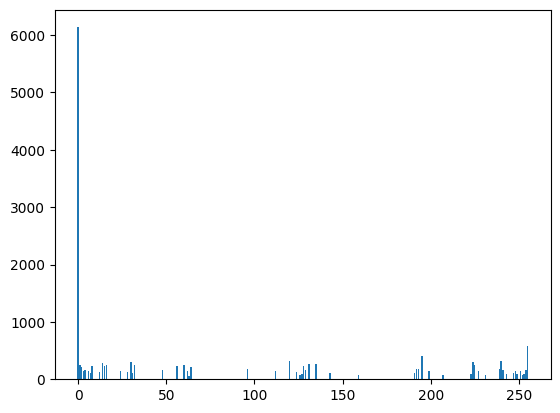

[477  19  69 245  15   3 231 349  66  52   4  82 175  37 223 307  29   6
  36 107   0   0  38  52 223  90  58 116 259  41 250 120  68  45  13  95
  48  16  96  90   5  21   0   7  64  14  48  14 221 127 105 198  55   3
  93  38 290 122  50  44 376  12 155  19  15   2  43  39   3   0  91  25
  59  26  19  22 103   5 115  28   2   0  12   4   0   0   6   0  51   6
  15   0  42   0  19   0 207  58 129 116 109   0 215  35  72  14   5   5
 138   5  52   4 360  39 115  34  43   0  39   0 357  24  10   1 153   0
  22   0  57 169   5 203  53  33  74 219   8  96   0  48 111  97  43 148
  57  98  20  92  12   3  14  25 122 207   3  39  91  36  12  19   7  52
   0  32  15  19   3  13   1   3   0   0   7   4   0   0  69 147   3  46
  24   2   8   0  43  58   0   0  19   3   0   0 203 307  46 291 111  35
 103 111 108 110   6  11 205  40  35  16  40  45  15  11   3   0   4   0
 108  39   6   3  41   0   1   0 329 445  39 149 136  22  45  19  41  19
   0   0  50   0   0   0 319 174  13  21  30   0   

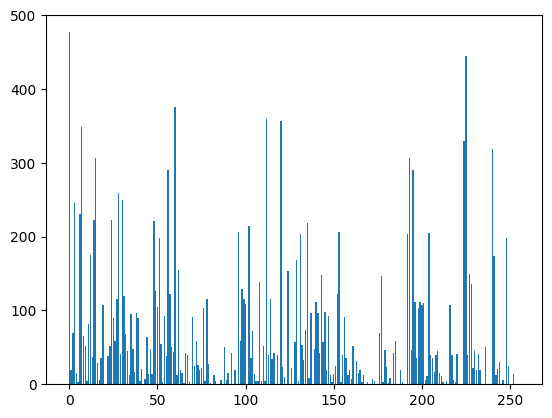

[2319  271  132  290  178   51  102  415  400   76   31  119  254   77
  183 1497  311   39   28   57   37    9   21   78   75   15    8   19
   38   17   36  269  140   25   21   15   12    5   14   27   26    6
    3    9   22    6   31  111  219   34   23   26   15    5   15   56
   32   10    4    7   19    6   29  132  130   18   16   20   15    5
    6   25   19    7    3    5   18    8   18   67   35    8    4    8
    4    3    2   11    5    3    1    6    4    4    8   28   83    8
    8   22    7    1    3   17   21    7    1    7   20    6   19   63
  175   32   17   26   12    7    8   38   22    7    1    7   18    9
   23  132  292   28   14   41   30    6    8   34   45    9    3   15
   26   10   22  131   47   11    1   13    5    3    5   19   15    3
    1    2    8    4    6   61   43    8    3    8    5    1    3   10
    8    2    1    7    5    6    9   47   57   12    3    7   10    4
    7   27   12    4    1    8   10    5    9   48  231   28   14   34
   22 

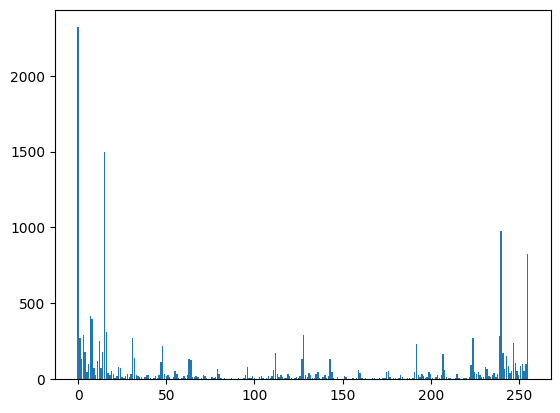

[603  24  13  11  21   0  24  14  13   0   0   0  23   0  58  25  17   0
   0   0   0   0   0   0  12   0   0   0  15   0  35  14  16   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0  14   0   0   0   0   0
   0   0  35   0   0   0  37   0   4   3  38   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0  27   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0  25   0   0   0   0   0   0   0  27   0   0   0  17   0
   7   9  17  16   0  60   0   0   0  24   0   0   0   0   0   0   0  12
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  12   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0  10  30  23   0  47   0   0
   0   7   0   0   0   0   0   0   0   5   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   8  70  32   0  16   0   0   0   6   0   0
   0   0   0   0   0  14  46  32   0  15   0   0   

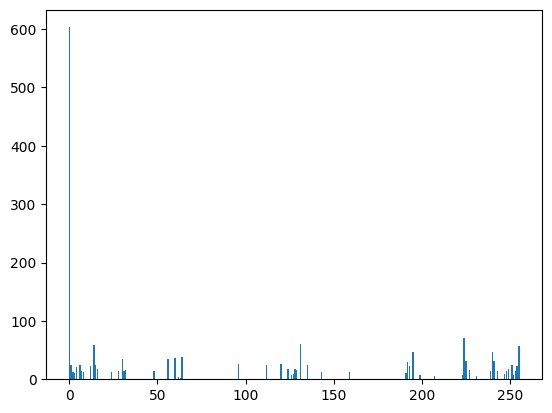

In [45]:
dum_lbp = get_lbp(np.array(X_train[0]))
dum_nlbp = get_nlbp(np.array(X_train[0]), 2)
dum_albp = get_albp(np.array(X_train[0]), 90)
dum_mblbp = get_mblbp(np.array(X_train[0]), 3)
print(dum_lbp)
plot_histogram(dum_lbp)
print(dum_nlbp)
plot_histogram(dum_nlbp)
print(dum_albp)
plot_histogram(dum_albp)
print(dum_mblbp)
plot_histogram(dum_mblbp)

### Execute Feature Extraction

In [15]:
# Define feature extracted data for training input
X_train_lbp, X_val_lbp = [], []
X_train_nlbp, X_val_nlbp = [], []
X_train_albp, X_val_albp = [], []

# Extract X_train images
for i, x in enumerate(X_train):
    X_train_lbp.append(get_lbp(x).flatten())
    X_train_nlbp.append(get_nlbp(x,1).flatten())
    X_train_albp.append(get_albp(x,0).flatten())
    print(f"{i}/{len(X_train)} X_train images extracted")

# Extract X_val images
for i, x in enumerate(X_val):
    X_val_lbp.append(get_lbp(x).flatten())
    X_val_nlbp.append(get_nlbp(x,1).flatten())
    X_val_albp.append(get_albp(x,0).flatten())
    print(f"{i}/{len(X_val)} X_val images extracted")

print("Image sample before feature extraction")
print(X_train[10])

print("Extracted image feature samples")
print(X_train_lbp[10])
print(X_train_nlbp[10])
print(X_train_albp[10])

0/2296 X_train images extracted
1/2296 X_train images extracted
2/2296 X_train images extracted
3/2296 X_train images extracted
4/2296 X_train images extracted
5/2296 X_train images extracted
6/2296 X_train images extracted
7/2296 X_train images extracted
8/2296 X_train images extracted
9/2296 X_train images extracted
10/2296 X_train images extracted
11/2296 X_train images extracted
12/2296 X_train images extracted
13/2296 X_train images extracted
14/2296 X_train images extracted
15/2296 X_train images extracted
16/2296 X_train images extracted
17/2296 X_train images extracted
18/2296 X_train images extracted
19/2296 X_train images extracted
20/2296 X_train images extracted
21/2296 X_train images extracted
22/2296 X_train images extracted
23/2296 X_train images extracted
24/2296 X_train images extracted
25/2296 X_train images extracted
26/2296 X_train images extracted
27/2296 X_train images extracted
28/2296 X_train images extracted
29/2296 X_train images extracted
30/2296 X_train imag

## Classification

### Evaluation Functions

In [16]:
def evaluate_model(model_name, y_val, model_preds, model_time):

    # Confusion matrix of trained model
    cm = confusion_matrix(y_val, model_preds)
    cm_disp = ConfusionMatrixDisplay(cm, display_labels=[c.removesuffix("_tumor") for c in classes])
    cm_disp.plot(cmap='cividis')
    plt.show()

    # Global performance measures
    tp, tn, fp, fn = 0, 0, 0, 0
    acc, prec, rec, f1 = 0, 0, 0, 0 
    local_perf = []

    # Evaluation matrices of trained model
    # Model predictions and performance for each classes and global-scoped
    for c in range(len(classes)):
        # Model predidctions for each class
        tp_c = cm[c,c]
        tp += tp_c
        
        tn_c = cm.sum() - cm[c,:].sum() - cm[:,c].sum() + cm[c,c]
        tn += tn_c

        fp_c = cm[:,c].sum() - cm[c,c]
        fp += fp_c

        fn_c = cm[c,:].sum() - cm[c,c]
        fn += fn_c

        # Model performance
        acc_c = (tp_c + tn_c) / (tp_c + tn_c + fp_c + fn_c)
        acc += acc_c / 4

        prec_c = tp_c / (tp_c + fp_c)
        prec += prec_c / 4

        rec_c = tp_c / (tp_c + fn_c)
        rec += rec_c / 4

        f1_c = 2 * ((prec_c * rec_c) / (prec_c + rec_c))
        f1 += f1_c / 4

        # Assign model performance of each class
        local_perf.append({
            "accuracy": acc_c,
            "precision": prec_c,
            "recall": rec_c,
            "f1-score": f1_c
        })

    acc_macro = (tp / cm.sum())

    # Assign model performance in global-scoped
    global_perf = { 
        "accuracy": acc, 
        "accuracy_macro": acc_macro, 
        "precision": prec,
        "recall": rec,
        "f1-score": f1
    }

    # Display model performance evaluation results
    display_evaluation(model_name, local_perf, global_perf, model_time)

    return local_perf, global_perf

def display_evaluation(model_name, local_perf, global_perf, model_time):
    print(f"Model & Params: {model_name}")
    print(f"Training Time : {model_time} seconds")

    for i, lp in enumerate(local_perf):
        print(f"\nLocal Performance for Class \"{classes[i]}\"")
        print(f"Accuracy : {lp["accuracy"]}",
              f"Precision: {lp["precision"]}",
              f"Recall   : {lp["recall"]}",
              f"F1-Score : {lp["f1-score"]}",
              sep="\n")
        
    print(f"\nGlobal Performance")
    print(f"Accuracy : {global_perf["accuracy"]} | {global_perf["accuracy_macro"]}",
          f"Precision: {global_perf["precision"]}",
          f"Recall   : {global_perf["recall"]}",
          f"F1-Score : {global_perf["f1-score"]}",
          sep="\n")


### Classic Machine Learning

#### K-Nearest Neighbor Model

- 3 Neighbors

In [17]:
# Define K-Nearest Neighbor model with 3 neighbors
knn_classifier_3 = KNeighborsClassifier(n_neighbors=3)

# Train LBP
start = time.perf_counter()
knn_classifier_3.fit(X_train_lbp, y_train)
end = time.perf_counter()
knn_3_lbp_time = end - start
# Test LBP
knn_3_lbp_preds = knn_classifier_3.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
knn_classifier_3.fit(X_train_nlbp, y_train)
end = time.perf_counter()
knn_3_nlbp_time = end - start
# Test nLBP
knn_3_nlbp_preds = knn_classifier_3.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
knn_classifier_3.fit(X_train_albp, y_train)
end = time.perf_counter()
knn_3_albp_time = end - start
# Test aLBP
knn_3_albp_preds = knn_classifier_3.predict(X_val_albp)

- 5 Neighbors

In [18]:
# Define K-Nearest Neighbor model with 5 neighbors
knn_classifier_5 = KNeighborsClassifier(n_neighbors=5)

# Train LBP
start = time.perf_counter()
knn_classifier_5.fit(X_train_lbp, y_train)
end = time.perf_counter()
knn_5_lbp_time = end - start
# Test LBP
knn_5_lbp_preds = knn_classifier_5.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
knn_classifier_5.fit(X_train_nlbp, y_train)
end = time.perf_counter()
knn_5_nlbp_time = end - start
# Test nLBP
knn_5_nlbp_preds = knn_classifier_5.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
knn_classifier_5.fit(X_train_albp, y_train)
end = time.perf_counter()
knn_5_albp_time = end - start
# Test aLBP
knn_5_albp_preds = knn_classifier_5.predict(X_val_albp)

- 7 Neighbors

In [19]:
# Define K-Nearest Neighbor model with 7 neighbors
knn_classifier_7 = KNeighborsClassifier(n_neighbors=7)

# Train LBP
start = time.perf_counter()
knn_classifier_7.fit(X_train_lbp, y_train)
end = time.perf_counter()
knn_7_lbp_time = end - start
# Test LBP
knn_7_lbp_preds = knn_classifier_7.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
knn_classifier_7.fit(X_train_nlbp, y_train)
end = time.perf_counter()
knn_7_nlbp_time = end - start
# Test nLBP
knn_7_nlbp_preds = knn_classifier_7.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
knn_classifier_7.fit(X_train_albp, y_train)
end = time.perf_counter()
knn_7_albp_time = end - start
# Test aLBP
knn_7_albp_preds = knn_classifier_7.predict(X_val_albp)

#### KNN Evaluation

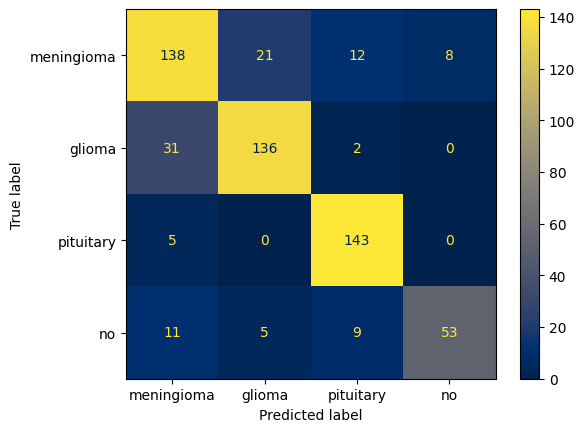

Model & Params: KNN - 3 Neighbors - LBP
Training Time : 0.0095008199999711 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8466898954703833
Precision: 0.745945945945946
Recall   : 0.770949720670391
F1-Score : 0.7582417582417582

Local Performance for Class "glioma_tumor"
Accuracy : 0.8972125435540069
Precision: 0.8395061728395061
Recall   : 0.8047337278106509
F1-Score : 0.8217522658610272

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9512195121951219
Precision: 0.8614457831325302
Recall   : 0.9662162162162162
F1-Score : 0.910828025477707

Local Performance for Class "no_tumor"
Accuracy : 0.9425087108013938
Precision: 0.8688524590163934
Recall   : 0.6794871794871795
F1-Score : 0.762589928057554

Global Performance
Accuracy : 0.9094076655052266 | 0.818815331010453
Precision: 0.8289375902335939
Recall   : 0.8053467110461094
F1-Score : 0.8133529944095116


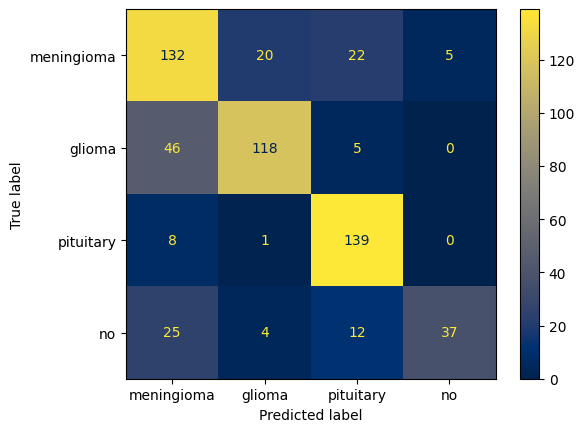

Model & Params: KNN - 3 Neighbors - nLBP
Training Time : 0.0042255260000274575 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7804878048780488
Precision: 0.6255924170616114
Recall   : 0.7374301675977654
F1-Score : 0.676923076923077

Local Performance for Class "glioma_tumor"
Accuracy : 0.867595818815331
Precision: 0.8251748251748252
Recall   : 0.6982248520710059
F1-Score : 0.7564102564102564

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9163763066202091
Precision: 0.7808988764044944
Recall   : 0.9391891891891891
F1-Score : 0.8527607361963191

Local Performance for Class "no_tumor"
Accuracy : 0.9198606271777003
Precision: 0.8809523809523809
Recall   : 0.47435897435897434
F1-Score : 0.6166666666666666

Global Performance
Accuracy : 0.8710801393728224 | 0.7421602787456446
Precision: 0.778154624898328
Recall   : 0.7123007958042337
F1-Score : 0.7256901840490798


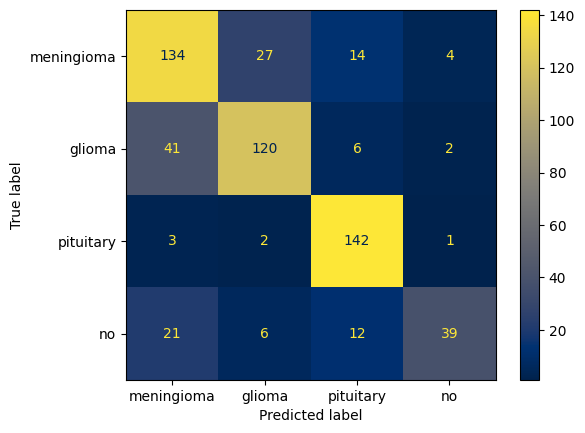

Model & Params: KNN - 3 Neighbors - aLBP
Training Time : 0.004034858000011354 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8083623693379791
Precision: 0.6733668341708543
Recall   : 0.7486033519553073
F1-Score : 0.708994708994709

Local Performance for Class "glioma_tumor"
Accuracy : 0.8536585365853658
Precision: 0.7741935483870968
Recall   : 0.7100591715976331
F1-Score : 0.7407407407407408

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9337979094076655
Precision: 0.8160919540229885
Recall   : 0.9594594594594594
F1-Score : 0.8819875776397516

Local Performance for Class "no_tumor"
Accuracy : 0.9198606271777003
Precision: 0.8478260869565217
Recall   : 0.5
F1-Score : 0.6290322580645161

Global Performance
Accuracy : 0.8789198606271776 | 0.7578397212543554
Precision: 0.7778696058843653
Recall   : 0.7295304957530999
F1-Score : 0.7401888213599294


In [20]:
# Evaluate KNN 3 Neighbors model classifier
knn_3_lbp_eval = evaluate_model("KNN - 3 Neighbors - LBP", y_val, knn_3_lbp_preds, knn_3_lbp_time)
knn_3_nlbp_eval = evaluate_model("KNN - 3 Neighbors - nLBP", y_val, knn_3_nlbp_preds, knn_3_nlbp_time)
knn_3_albp_eval = evaluate_model("KNN - 3 Neighbors - aLBP", y_val, knn_3_albp_preds, knn_3_albp_time)

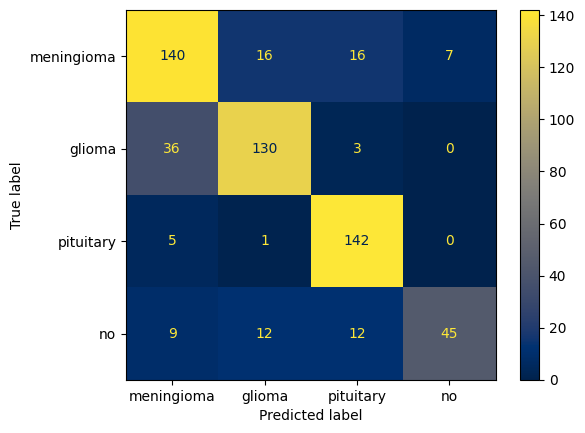

Model & Params: KNN - 5 Neighbors - LBP
Training Time : 0.005044692000012674 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8449477351916377
Precision: 0.7368421052631579
Recall   : 0.7821229050279329
F1-Score : 0.7588075880758808

Local Performance for Class "glioma_tumor"
Accuracy : 0.8815331010452961
Precision: 0.8176100628930818
Recall   : 0.7692307692307693
F1-Score : 0.7926829268292683

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9355400696864111
Precision: 0.8208092485549133
Recall   : 0.9594594594594594
F1-Score : 0.8847352024922117

Local Performance for Class "no_tumor"
Accuracy : 0.9303135888501742
Precision: 0.8653846153846154
Recall   : 0.5769230769230769
F1-Score : 0.6923076923076923

Global Performance
Accuracy : 0.8980836236933799 | 0.7961672473867596
Precision: 0.810161508023942
Recall   : 0.7719340526603096
F1-Score : 0.7821333524262633


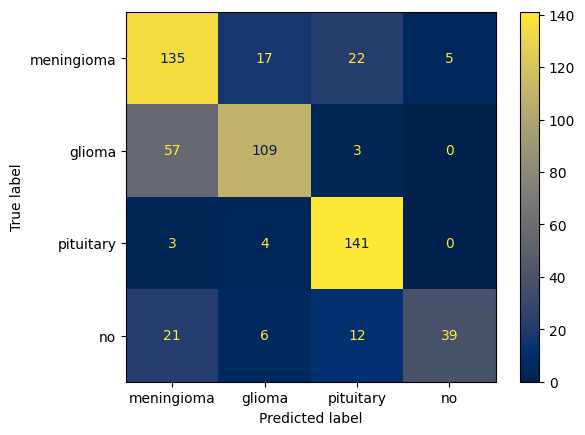

Model & Params: KNN - 5 Neighbors - nLBP
Training Time : 0.0042794270000285906 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7822299651567944
Precision: 0.625
Recall   : 0.7541899441340782
F1-Score : 0.6835443037974683

Local Performance for Class "glioma_tumor"
Accuracy : 0.8484320557491289
Precision: 0.8014705882352942
Recall   : 0.6449704142011834
F1-Score : 0.7147540983606558

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9233449477351916
Precision: 0.7921348314606742
Recall   : 0.9527027027027027
F1-Score : 0.8650306748466258

Local Performance for Class "no_tumor"
Accuracy : 0.9233449477351916
Precision: 0.8863636363636364
Recall   : 0.5
F1-Score : 0.639344262295082

Global Performance
Accuracy : 0.8693379790940767 | 0.7386759581881533
Precision: 0.7762422640149012
Recall   : 0.7129657652594911
F1-Score : 0.725668334824958


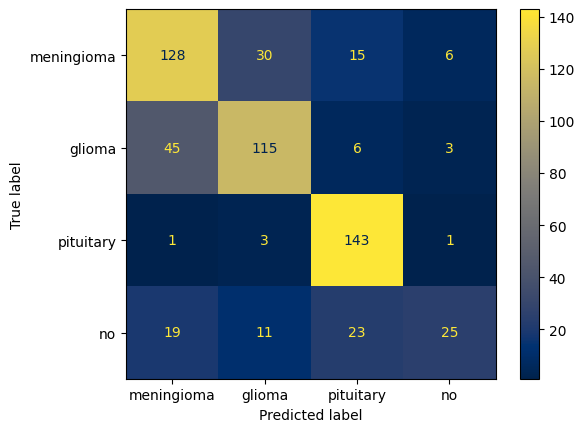

Model & Params: KNN - 5 Neighbors - aLBP
Training Time : 0.004131549999954132 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7979094076655052
Precision: 0.6632124352331606
Recall   : 0.7150837988826816
F1-Score : 0.6881720430107526

Local Performance for Class "glioma_tumor"
Accuracy : 0.8292682926829268
Precision: 0.7232704402515723
Recall   : 0.6804733727810651
F1-Score : 0.7012195121951219

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9146341463414634
Precision: 0.7647058823529411
Recall   : 0.9662162162162162
F1-Score : 0.8537313432835821

Local Performance for Class "no_tumor"
Accuracy : 0.8902439024390244
Precision: 0.7142857142857143
Recall   : 0.32051282051282054
F1-Score : 0.4424778761061947

Global Performance
Accuracy : 0.85801393728223 | 0.7160278745644599
Precision: 0.7163686180308471
Recall   : 0.670571552098196
F1-Score : 0.6714001936489129


In [21]:
# Evaluate KNN 5 Neighbors model classifier
knn_5_lbp_eval = evaluate_model("KNN - 5 Neighbors - LBP", y_val, knn_5_lbp_preds, knn_5_lbp_time)
knn_5_nlbp_eval = evaluate_model("KNN - 5 Neighbors - nLBP", y_val, knn_5_nlbp_preds, knn_5_nlbp_time)
knn_5_albp_eval = evaluate_model("KNN - 5 Neighbors - aLBP", y_val, knn_5_albp_preds, knn_5_albp_time)

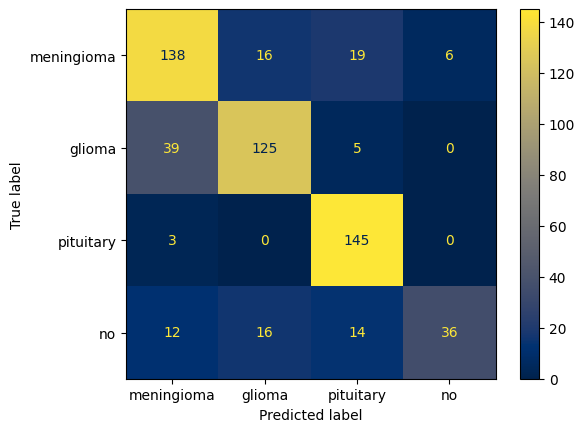

Model & Params: KNN - 7 Neighbors - LBP
Training Time : 0.005545712000014191 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8344947735191638
Precision: 0.71875
Recall   : 0.770949720670391
F1-Score : 0.7439353099730457

Local Performance for Class "glioma_tumor"
Accuracy : 0.867595818815331
Precision: 0.7961783439490446
Recall   : 0.7396449704142012
F1-Score : 0.7668711656441718

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9285714285714286
Precision: 0.7923497267759563
Recall   : 0.9797297297297297
F1-Score : 0.8761329305135952

Local Performance for Class "no_tumor"
Accuracy : 0.9163763066202091
Precision: 0.8571428571428571
Recall   : 0.46153846153846156
F1-Score : 0.6

Global Performance
Accuracy : 0.886759581881533 | 0.7735191637630662
Precision: 0.7911052319669646
Recall   : 0.7379657205881959
F1-Score : 0.7467348515327031


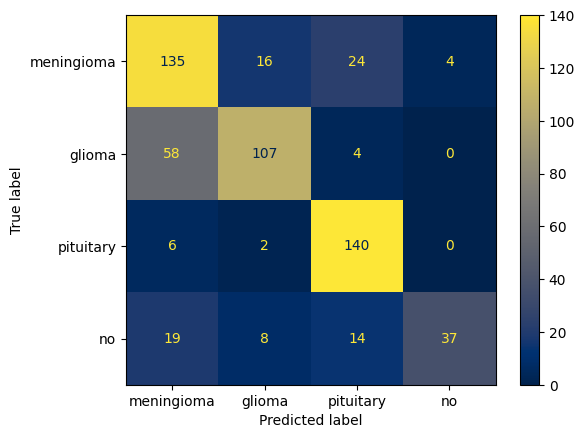

Model & Params: KNN - 7 Neighbors - nLBP
Training Time : 0.004242116000000351 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7787456445993032
Precision: 0.6192660550458715
Recall   : 0.7541899441340782
F1-Score : 0.6801007556675063

Local Performance for Class "glioma_tumor"
Accuracy : 0.8466898954703833
Precision: 0.8045112781954887
Recall   : 0.6331360946745562
F1-Score : 0.7086092715231788

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9128919860627178
Precision: 0.7692307692307693
Recall   : 0.9459459459459459
F1-Score : 0.8484848484848485

Local Performance for Class "no_tumor"
Accuracy : 0.921602787456446
Precision: 0.9024390243902439
Recall   : 0.47435897435897434
F1-Score : 0.6218487394957983

Global Performance
Accuracy : 0.8649825783972125 | 0.7299651567944251
Precision: 0.7738617817155933
Recall   : 0.7019077397783887
F1-Score : 0.714760903792833


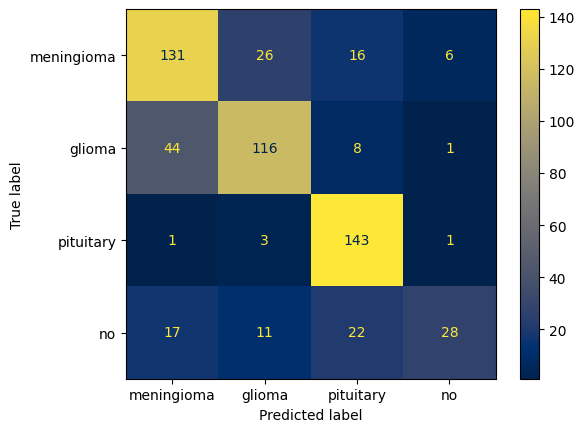

Model & Params: KNN - 7 Neighbors - aLBP
Training Time : 0.0040270430000077795 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.8083623693379791
Precision: 0.6787564766839378
Recall   : 0.7318435754189944
F1-Score : 0.7043010752688171

Local Performance for Class "glioma_tumor"
Accuracy : 0.837979094076655
Precision: 0.7435897435897436
Recall   : 0.6863905325443787
F1-Score : 0.7138461538461539

Local Performance for Class "pituitary_tumor"
Accuracy : 0.9111498257839721
Precision: 0.7566137566137566
Recall   : 0.9662162162162162
F1-Score : 0.8486646884272997

Local Performance for Class "no_tumor"
Accuracy : 0.8989547038327527
Precision: 0.7777777777777778
Recall   : 0.358974358974359
F1-Score : 0.49122807017543857

Global Performance
Accuracy : 0.8641114982578397 | 0.7282229965156795
Precision: 0.7391844386663039
Recall   : 0.685856170788487
F1-Score : 0.6895099969294274


In [22]:
# Evaluate KNN 7 Neighbors model classifier
knn_7_lbp_eval = evaluate_model("KNN - 7 Neighbors - LBP", y_val, knn_7_lbp_preds, knn_7_lbp_time)
knn_7_nlbp_eval = evaluate_model("KNN - 7 Neighbors - nLBP", y_val, knn_7_nlbp_preds, knn_7_nlbp_time)
knn_7_albp_eval = evaluate_model("KNN - 7 Neighbors - aLBP", y_val, knn_7_albp_preds, knn_7_albp_time)

#### Decision Tree

In [23]:
# Define Decision Tree model with 3 max tree depth
dt_3_classifier = DecisionTreeClassifier(max_depth=3)

# Train LBP
start = time.perf_counter()
dt_3_classifier.fit(X_train_lbp, y_train)
end = time.perf_counter()
dt_3_lbp_time = end - start
# Test LBP
dt_3_lbp_preds = dt_3_classifier.predict(X_val_lbp)

# Train nLBP
start = time.perf_counter()
dt_3_classifier.fit(X_train_nlbp, y_train)
end = time.perf_counter()
dt_3_nlbp_time = end - start
# Test nLBP
dt_3_nlbp_preds = dt_3_classifier.predict(X_val_nlbp)

# Train aLBP
start = time.perf_counter()
dt_3_classifier.fit(X_train_albp, y_train)
end = time.perf_counter()
dt_3_albp_time = end - start
# Test aLBP
dt_3_albp_preds = dt_3_classifier.predict(X_val_albp)

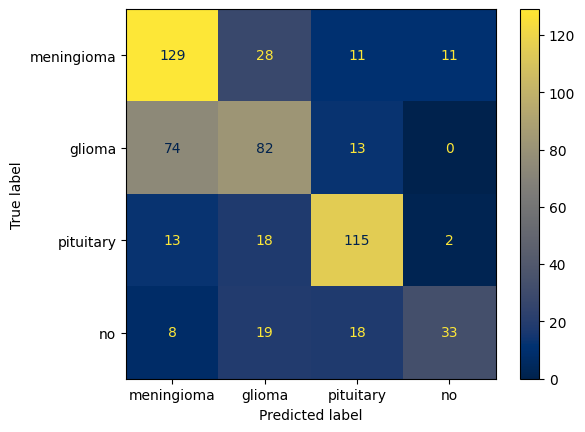

Model & Params: DT - 3 Neighbors - LBP
Training Time : 0.02416709900001024 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7473867595818815
Precision: 0.5758928571428571
Recall   : 0.7206703910614525
F1-Score : 0.6401985111662531

Local Performance for Class "glioma_tumor"
Accuracy : 0.735191637630662
Precision: 0.5578231292517006
Recall   : 0.48520710059171596
F1-Score : 0.5189873417721519

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8693379790940766
Precision: 0.732484076433121
Recall   : 0.777027027027027
F1-Score : 0.7540983606557377

Local Performance for Class "no_tumor"
Accuracy : 0.8989547038327527
Precision: 0.717391304347826
Recall   : 0.4230769230769231
F1-Score : 0.532258064516129

Global Performance
Accuracy : 0.8127177700348432 | 0.6254355400696864
Precision: 0.6458978417938762
Recall   : 0.6014953604392796
F1-Score : 0.611385569527568


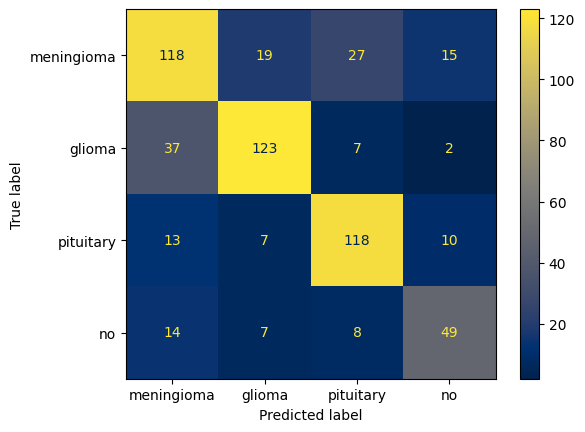

Model & Params: DT - 3 Neighbors - nLBP
Training Time : 0.014873538000017561 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7822299651567944
Precision: 0.6483516483516484
Recall   : 0.659217877094972
F1-Score : 0.6537396121883657

Local Performance for Class "glioma_tumor"
Accuracy : 0.8623693379790941
Precision: 0.7884615384615384
Recall   : 0.727810650887574
F1-Score : 0.7569230769230769

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8745644599303136
Precision: 0.7375
Recall   : 0.7972972972972973
F1-Score : 0.7662337662337663

Local Performance for Class "no_tumor"
Accuracy : 0.9024390243902439
Precision: 0.6447368421052632
Recall   : 0.6282051282051282
F1-Score : 0.6363636363636362

Global Performance
Accuracy : 0.8554006968641115 | 0.710801393728223
Precision: 0.7047625072296125
Recall   : 0.7031327383712429
F1-Score : 0.7033150229272113


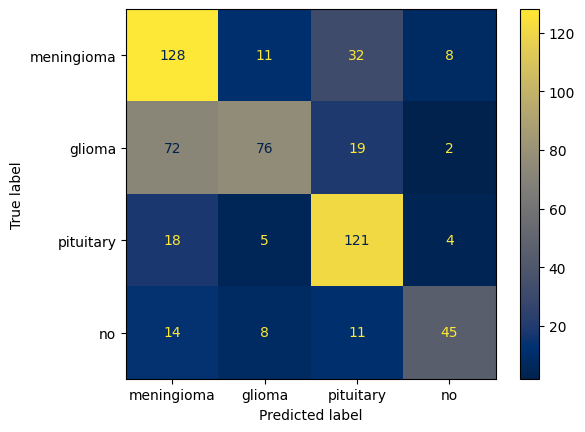

Model & Params: DT - 3 Neighbors - aLBP
Training Time : 0.01697605999999041 seconds

Local Performance for Class "meningioma_tumor"
Accuracy : 0.7299651567944251
Precision: 0.5517241379310345
Recall   : 0.7150837988826816
F1-Score : 0.6228710462287106

Local Performance for Class "glioma_tumor"
Accuracy : 0.7961672473867596
Precision: 0.76
Recall   : 0.44970414201183434
F1-Score : 0.5650557620817844

Local Performance for Class "pituitary_tumor"
Accuracy : 0.8449477351916377
Precision: 0.6612021857923497
Recall   : 0.8175675675675675
F1-Score : 0.7311178247734138

Local Performance for Class "no_tumor"
Accuracy : 0.9181184668989547
Precision: 0.7627118644067796
Recall   : 0.5769230769230769
F1-Score : 0.656934306569343

Global Performance
Accuracy : 0.8222996515679443 | 0.6445993031358885
Precision: 0.6839095470325409
Recall   : 0.6398196463462901
F1-Score : 0.6439947349133129


In [24]:
# Evaluate Decision Tree 3 depth model classifier
dt_3_lbp_eval = evaluate_model("DT - 3 Neighbors - LBP", y_val, dt_3_lbp_preds, dt_3_lbp_time)
dt_3_nlbp_eval = evaluate_model("DT - 3 Neighbors - nLBP", y_val, dt_3_nlbp_preds, dt_3_nlbp_time)
dt_3_albp_eval = evaluate_model("DT - 3 Neighbors - aLBP", y_val, dt_3_albp_preds, dt_3_albp_time)

In [25]:
# Define Decision Tree model classifier
dt_3_classifier = DecisionTreeClassifier()

# Train Decision Tree model classifier
dt_3_classifier.fit(X_train, y_train)

# Test Decision Tree model classifier
dt_preds = dt_3_classifier.predict(X_val)

ValueError: Found array with dim 3, while dim <= 2 is required by DecisionTreeClassifier.

In [ ]:
# Evaluate Decision Tree model classifier
dt_eval = evaluate_model("Decision Tree", y_val, dt_preds)

### Random Forest

In [ ]:
# Define Random Forest model classifier
rf_classifier = RandomForestClassifier()

# Train Random Forest model classifier
rf_classifier.fit(X_train, y_train)

# Test Random Forest model classifier
rf_preds = rf_classifier.predict(X_val)

# Evaluate Random Forest model classifier
rf_eval = evaluate_model("Random Forest", y_val, rf_preds)

### Naive Bayes

In [ ]:
# Define Naive Bayes model classifier
gnb_classifier = GaussianNB()

# Train Naive Bayes model classifier
gnb_classifier.fit(X_train, y_train)

# Test Naive Bayes model classifier
gnb_preds = gnb_classifier.predict(X_val)

# Evaluate Naive Bayes model classifier
gnb_eval = evaluate_model("Gaussian Naive Bayes", y_val, gnb_preds)

In [ ]:
# Define Naive Bayes model classifier
mnb_classifier = MultinomialNB()

# Train Naive Bayes model classifier
mnb_classifier.fit(X_train, y_train)

# Test Naive Bayes model classifier
mnb_preds = mnb_classifier.predict(X_val)

# Evaluate Naive Bayes model classifier
mnb_eval = evaluate_model("Multinomial Naive Bayes", y_val, mnb_preds)

#### Support Vector Machine

In [ ]:
# classifier = SVC()
# classifier.fit(X_train, y_train)

# classifier.predict(X_test)